In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os.path as path
import seaborn as sns

## 1.Melihat Karakteristik Dataset

In [56]:
df = pd.read_csv('../0.dataset/California_House_Price.csv',nrows=2000)
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
5,-122.25,37.85,52,919,213.0,413,193,4.0368,NEAR BAY,269700
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,NEAR BAY,299200
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,NEAR BAY,241400
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,NEAR BAY,226700
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,NEAR BAY,261100


In [57]:
df.isnull().sum()

longitude              0
latitude               0
housing_median_age     0
total_rooms            0
total_bedrooms        11
population             0
households             0
median_income          0
ocean_proximity        0
median_house_value     0
dtype: int64

In [73]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.shape

(2000, 10)

In [60]:
df = df.drop(columns='Id' , errors='ignore')
df.shape

(2000, 10)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           2000 non-null   float64
 1   latitude            2000 non-null   float64
 2   housing_median_age  2000 non-null   int64  
 3   total_rooms         2000 non-null   int64  
 4   total_bedrooms      1989 non-null   float64
 5   population          2000 non-null   int64  
 6   households          2000 non-null   int64  
 7   median_income       2000 non-null   float64
 8   ocean_proximity     2000 non-null   object 
 9   median_house_value  2000 non-null   int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 156.4+ KB


In [62]:
feature_numerik = df.select_dtypes(include=np.number).drop(columns='median_house_value').columns
feauture_categori = df.select_dtypes(include='object').columns
feauture_target = 'median_house_value'
feature_numerik

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [63]:
df[feature_numerik].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,2000.000000,2000.000000,2000.000000,2000.000000,1989.000000,2000.000000,2000.000000,2000.000000
mean,-121.940045,38.066565,31.310500,2597.088000,503.105078,1243.354500,468.169000,3.885417
std,0.571707,0.655932,14.050331,2109.100036,380.126756,965.900959,359.921934,1.910350
min,-124.300000,36.720000,2.000000,12.000000,4.000000,18.000000,7.000000,0.499900
25%,-122.240000,37.740000,19.000000,1407.750000,279.000000,691.000000,260.000000,2.536800
50%,-122.090000,37.860000,32.000000,2084.000000,406.000000,1002.500000,377.000000,3.508600
75%,-121.900000,37.992500,43.000000,3087.750000,606.000000,1495.000000,556.250000,4.924075
max,-119.770000,41.950000,52.000000,28258.000000,3864.000000,12203.000000,3701.000000,15.000100


## 2.Analisis Univariat

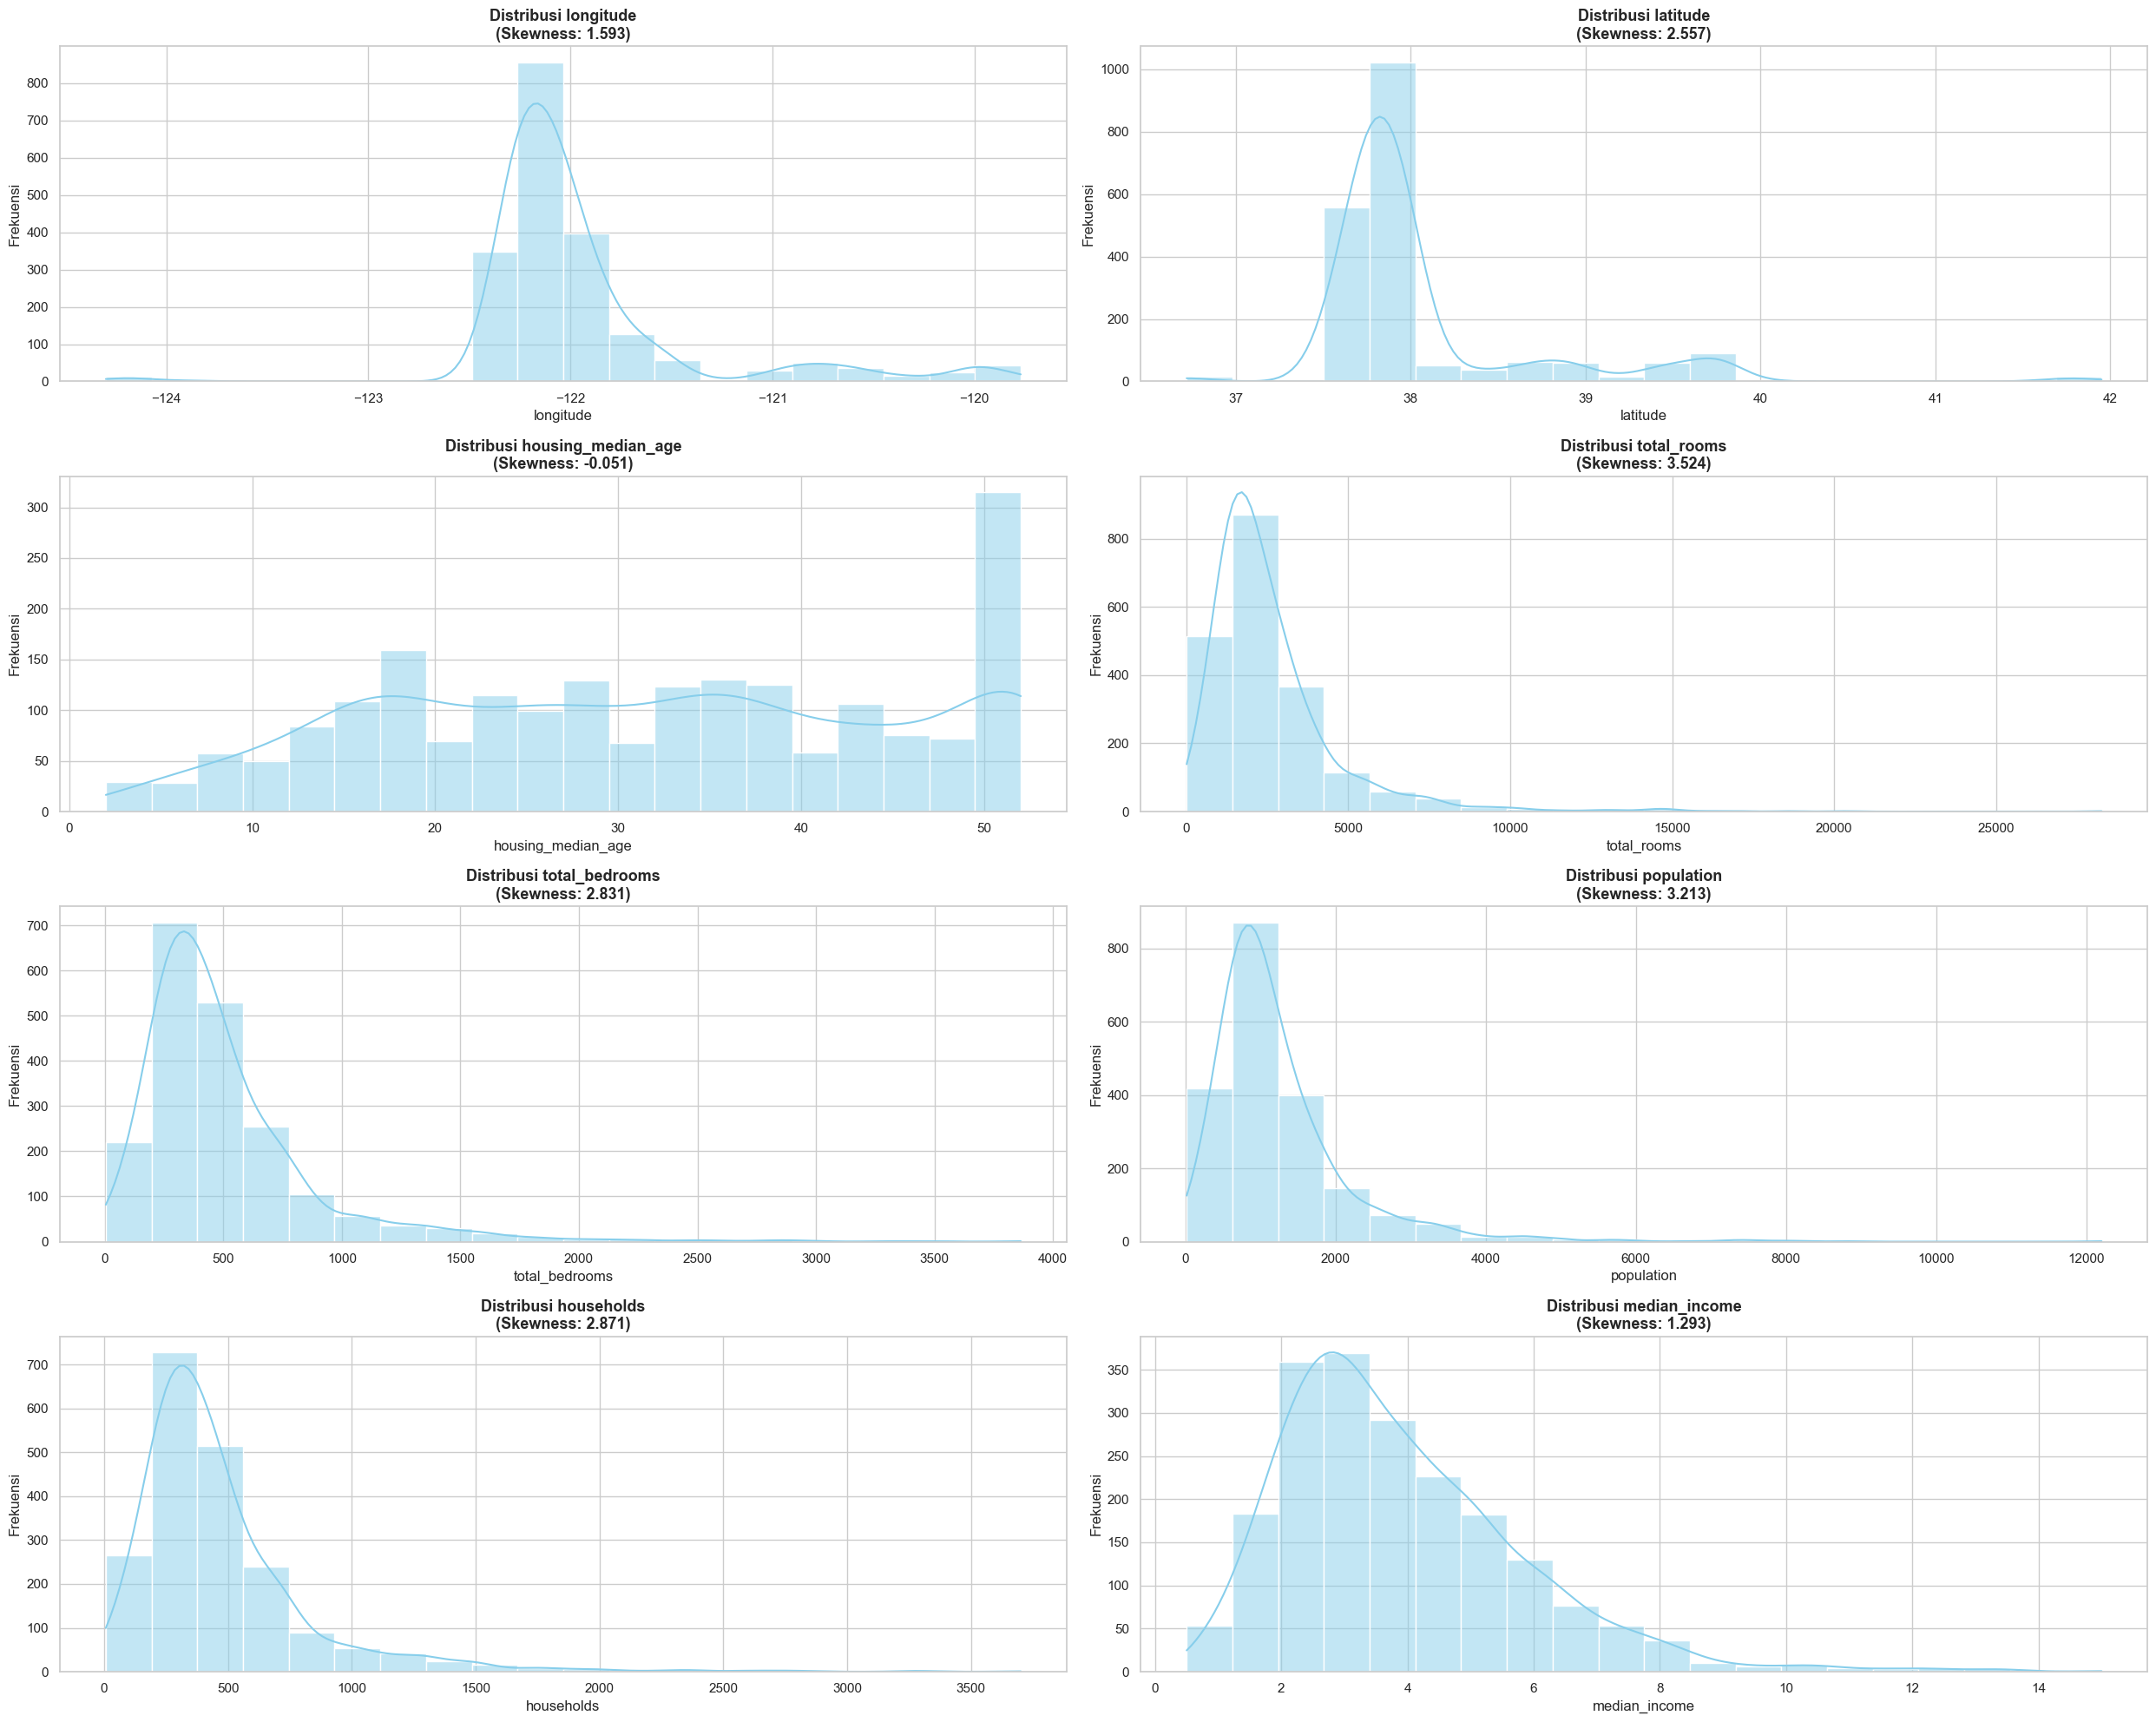

In [64]:
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(4,2,figsize=(25,20))
axes = axes.flatten()

for i,feature in enumerate(feature_numerik):
    feat_skew = df[feature].skew()
    sns.histplot(df[feature],ax=axes[i],kde=True,color='skyblue',bins=20)
    axes[i].set_title( f"Distribusi {feature}\n(Skewness: {feat_skew:.3f})",fontsize=13,fontweight="bold")
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Frekuensi", fontsize=12)
plt.tight_layout()
plt.show()

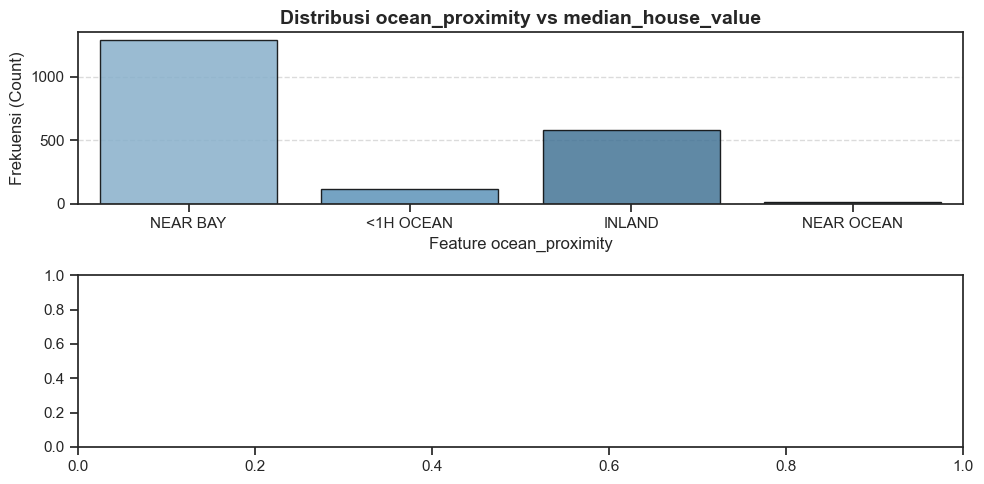

In [65]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 1, figsize=(10,5))
axes = axes.flatten()

for i, feature in enumerate(feauture_categori):
    sns.countplot(data=df,x=feature,hue=feature,ax= axes[i],palette='Blues_d',edgecolor="black",alpha=0.85,)
    axes[i].set_title(f"Distribusi {feature} vs {feauture_target}",fontsize=14,fontweight="bold",)
    axes[i].set_xlabel(f"Feature {feature}", fontsize=12)
    axes[i].set_ylabel("Frekuensi (Count)", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## 3.Analisis Bivariat

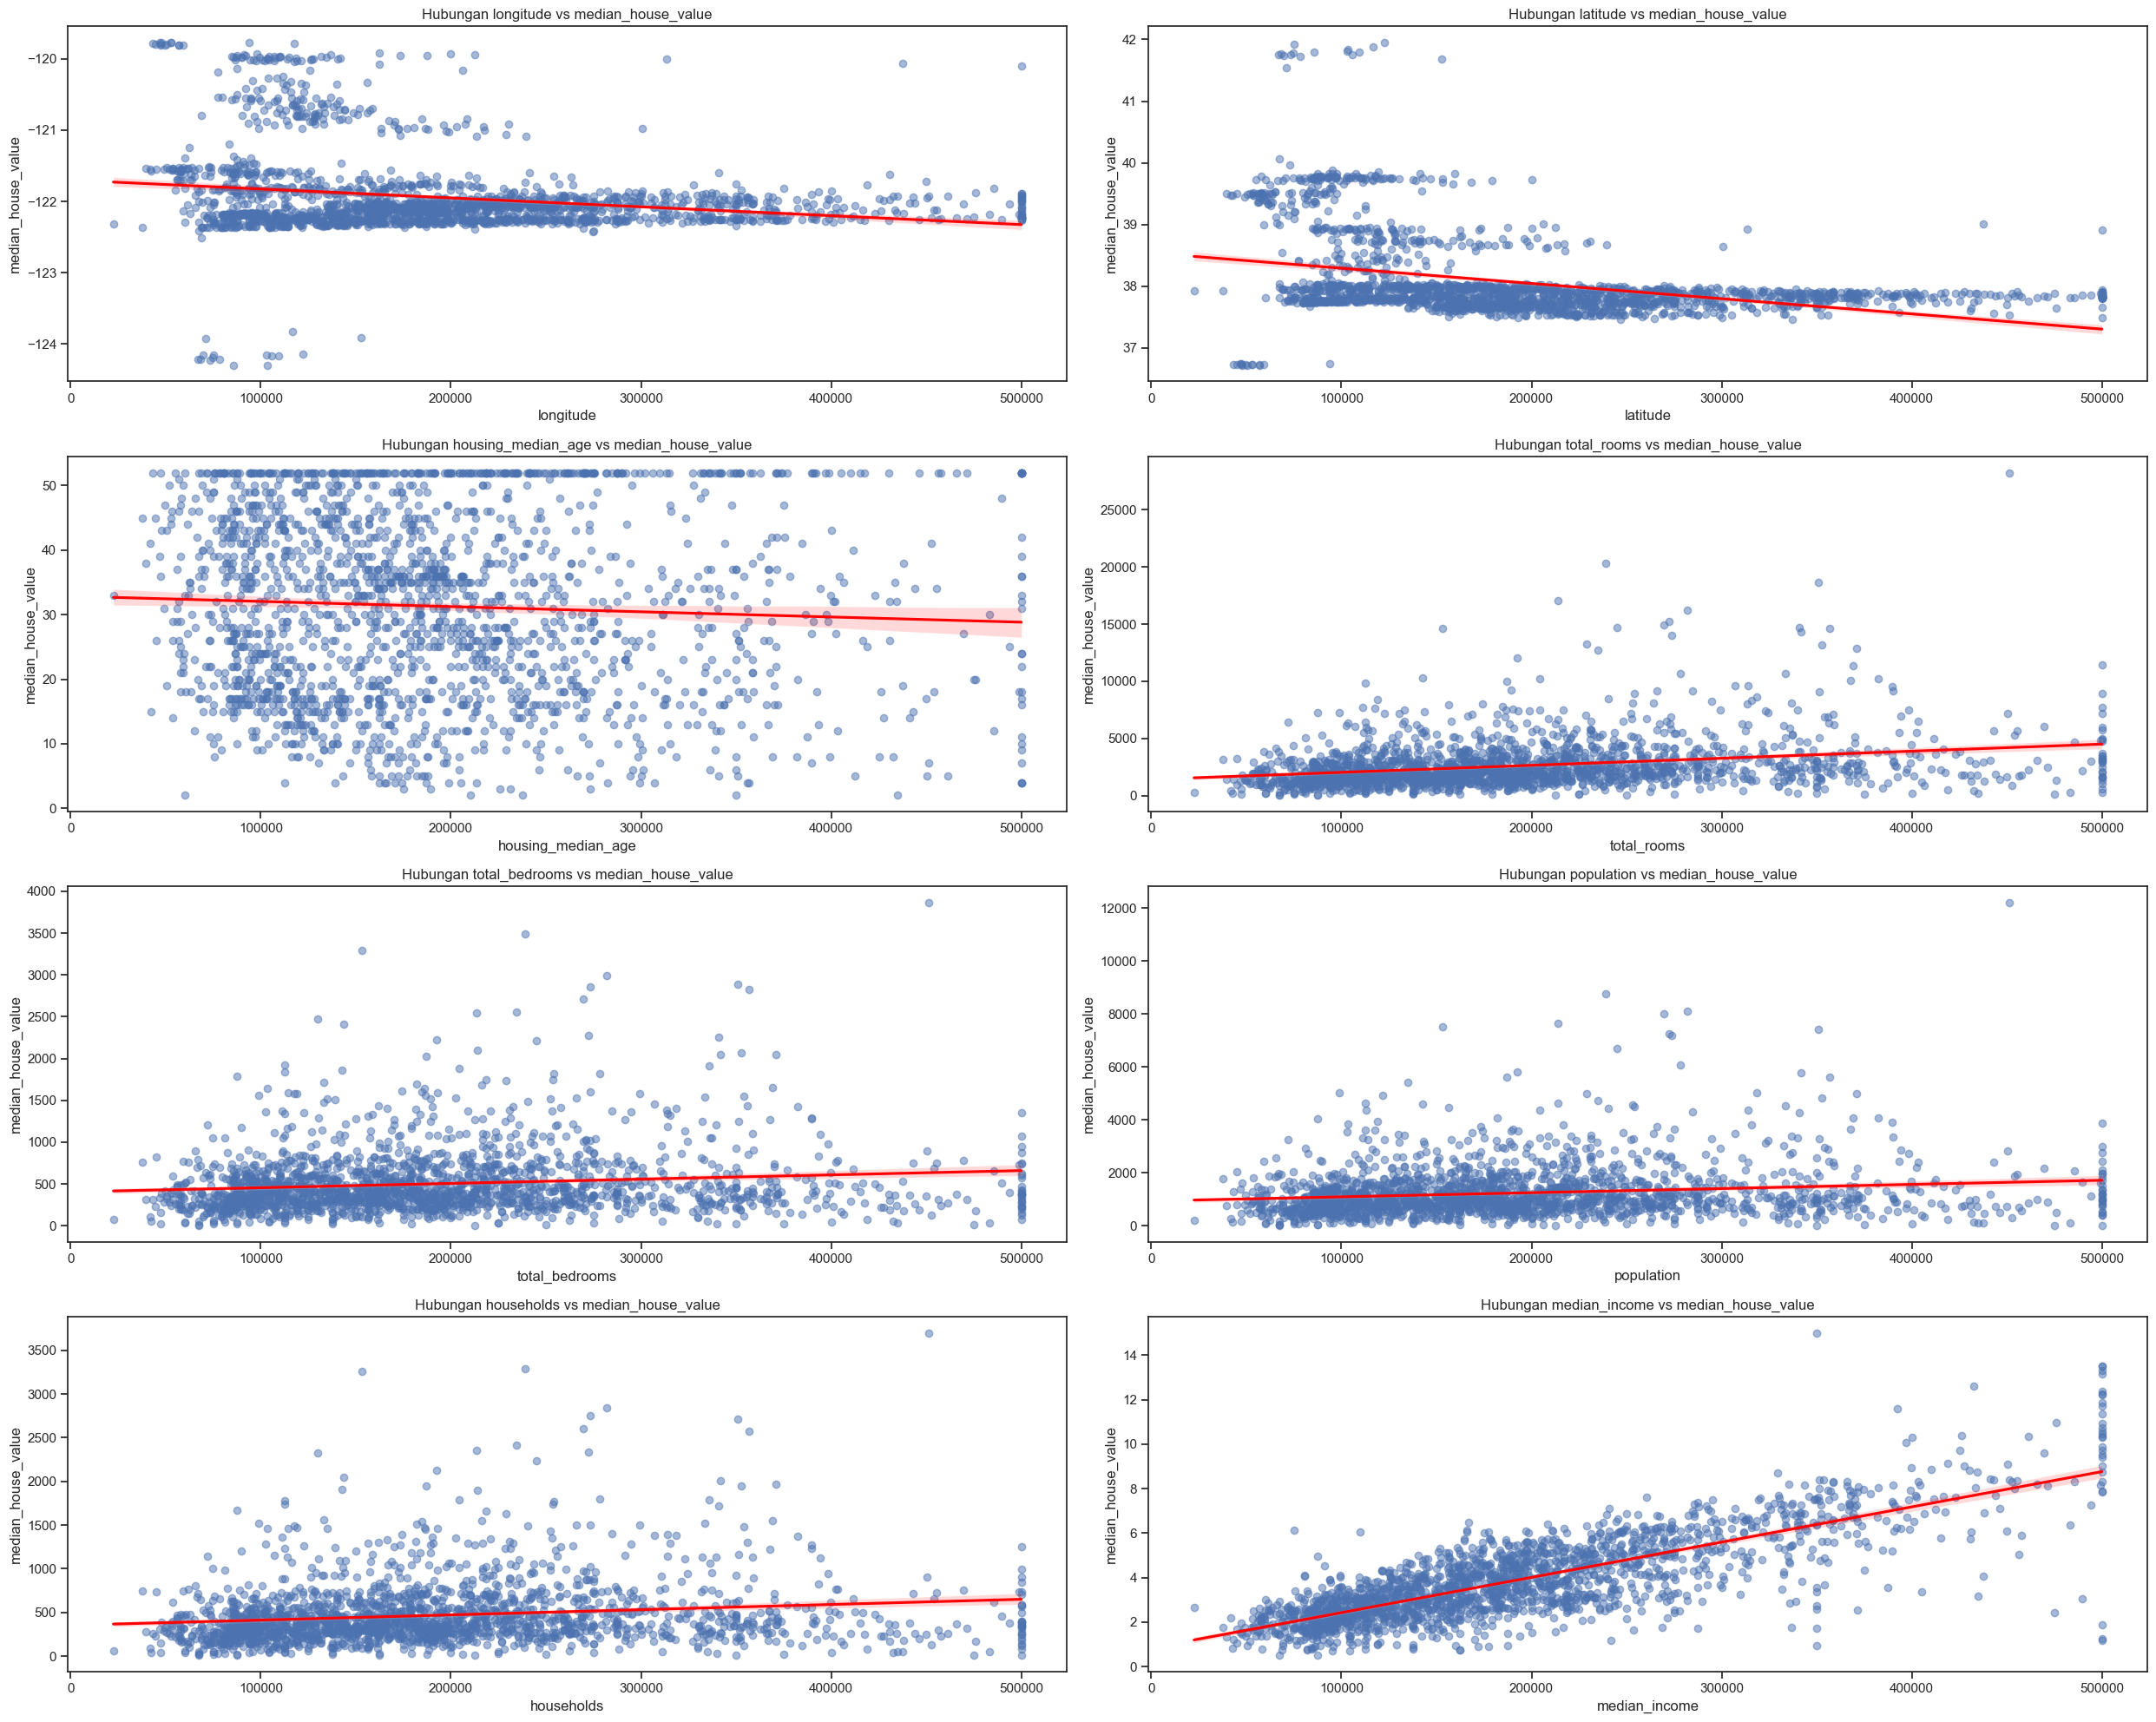

In [66]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(4, 2, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.regplot(data=df, x=feauture_target, y=col, ax=axes[i], scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    #sns.scatterplot(data=df, x=feauture_target, y=col, ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Hubungan {col} vs {feauture_target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(feauture_target)  # Hanya tampilkan label Y di grafik pertama

plt.tight_layout()
plt.show()

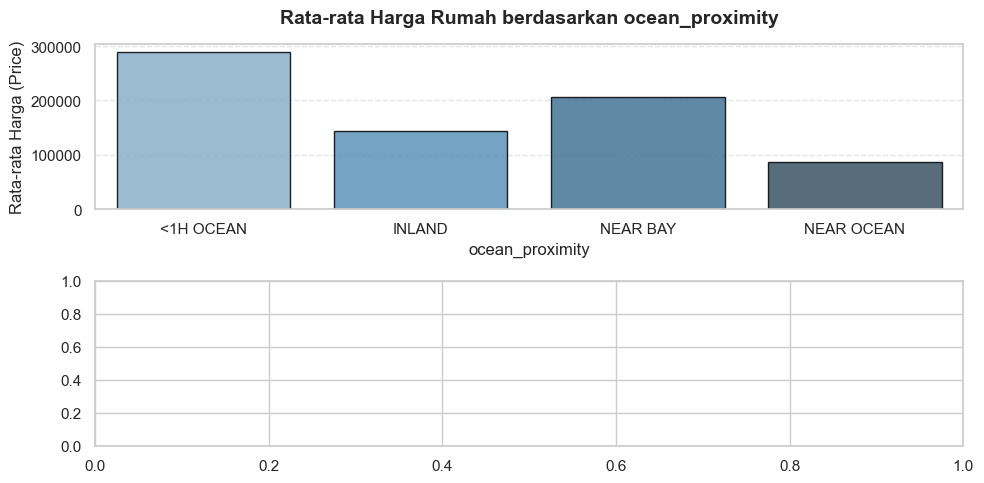

In [67]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10,5))
axes = axes.flatten()

for i, feature in enumerate(feauture_categori):
    mean_df = df.groupby(feature)[feauture_target].mean().abs().reset_index()
    sns.barplot(data=mean_df, x=feature,  y=feauture_target, hue=feature, legend=False,ax=axes[i],palette="Blues_d",edgecolor="black",alpha=0.85)
    axes[i].set_title(f"Rata-rata Harga Rumah berdasarkan {feature}",fontsize=14,fontweight="bold",pad=15)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("Rata-rata Harga (Price)", fontsize=12)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Analisis Multivariat

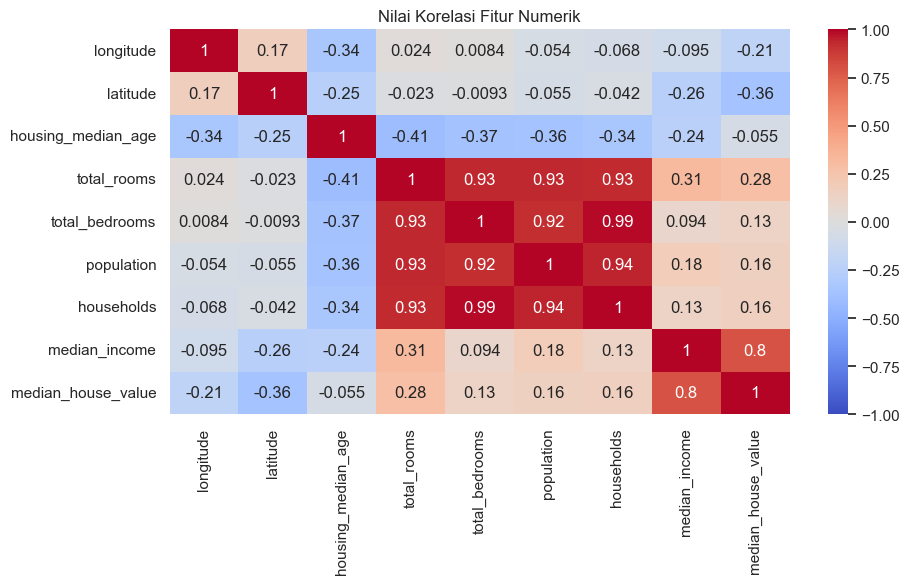

In [68]:
plt.figure(figsize=(10, 5))
correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",vmin=-1,vmax=1,)
plt.title(f"Nilai Korelasi Fitur Numerik")
plt.show()

## 6. Analisis Outliers

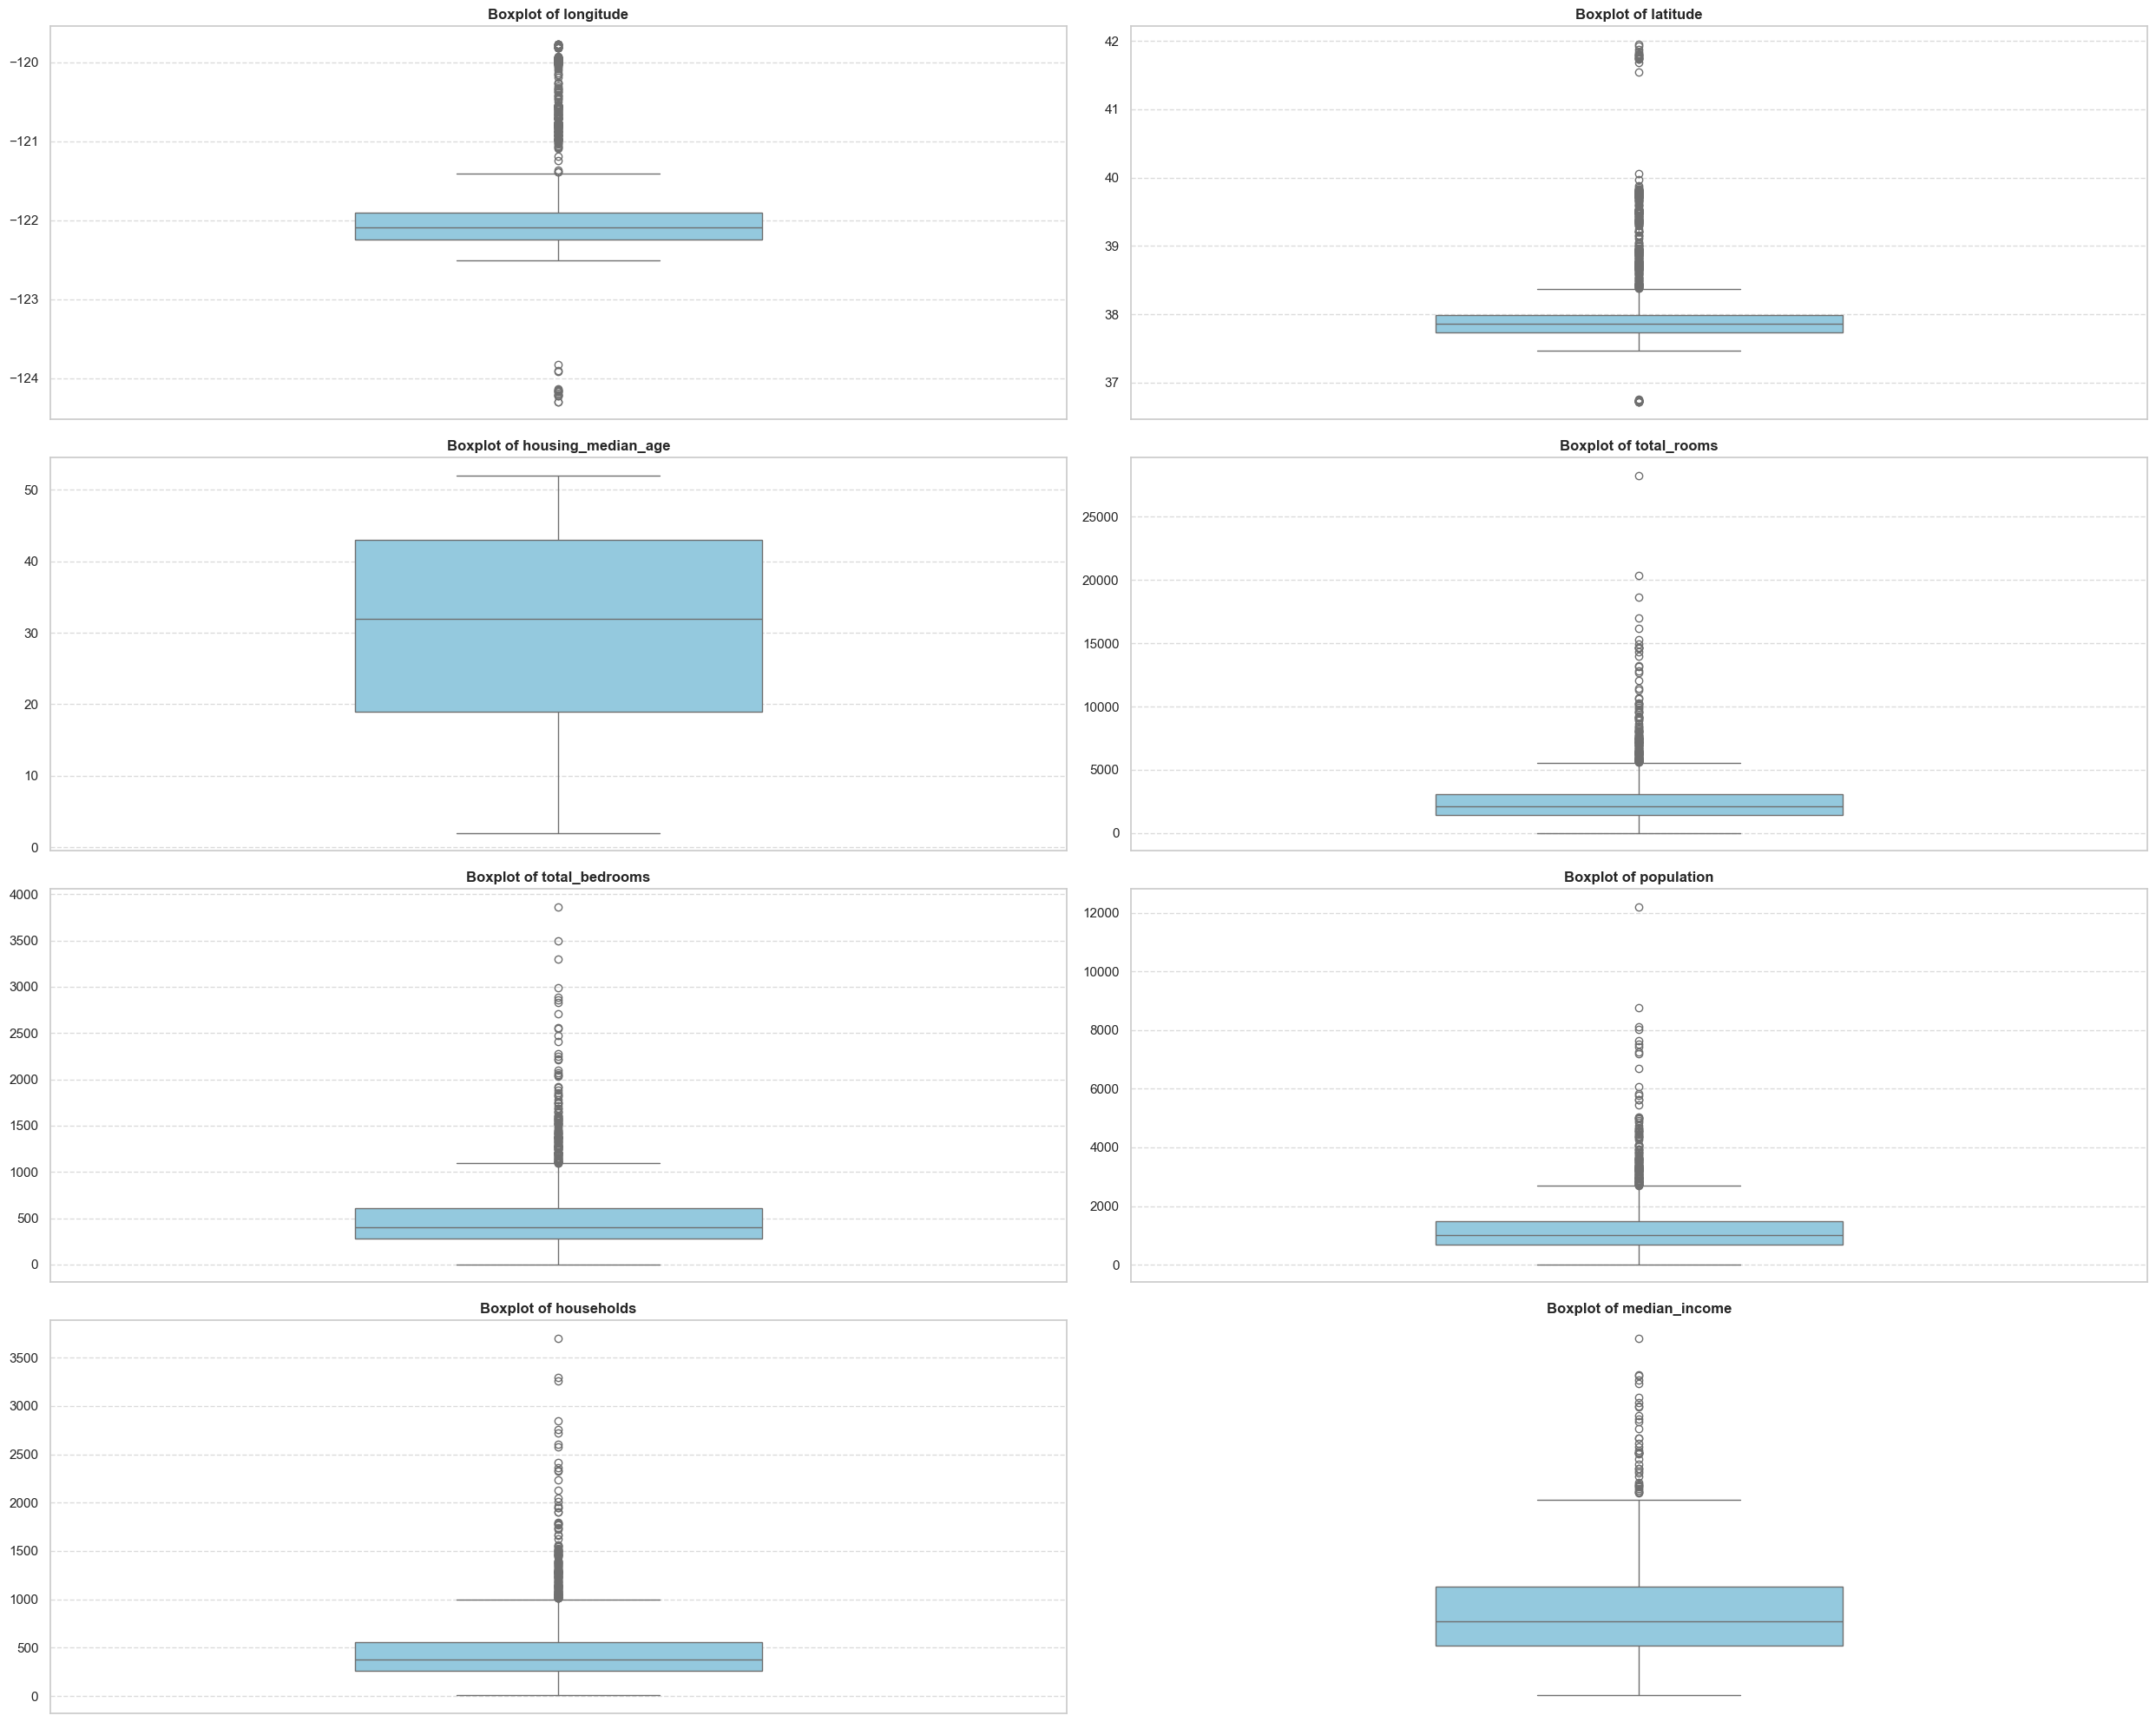

Jumlah outliers terdeteksi: 577


In [69]:
Q1 = df[feature_numerik].quantile(0.25)
Q3 = df[feature_numerik].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df.loc[((df[feature_numerik] < lower_bound) | (df[feature_numerik] > upper_bound)).any(axis=1)]

fig, axes = plt.subplots(4, 2 ,figsize=(25,20))
axes = axes.flatten()

for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Mengosongkan label y agar lebih bersih
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu
axes[-1].axis('off')
plt.tight_layout()
plt.show()

print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

## 7.Handling Missing Value and Remove Outliers

In [70]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df['total_bedrooms'].isnull().sum()

np.int64(0)

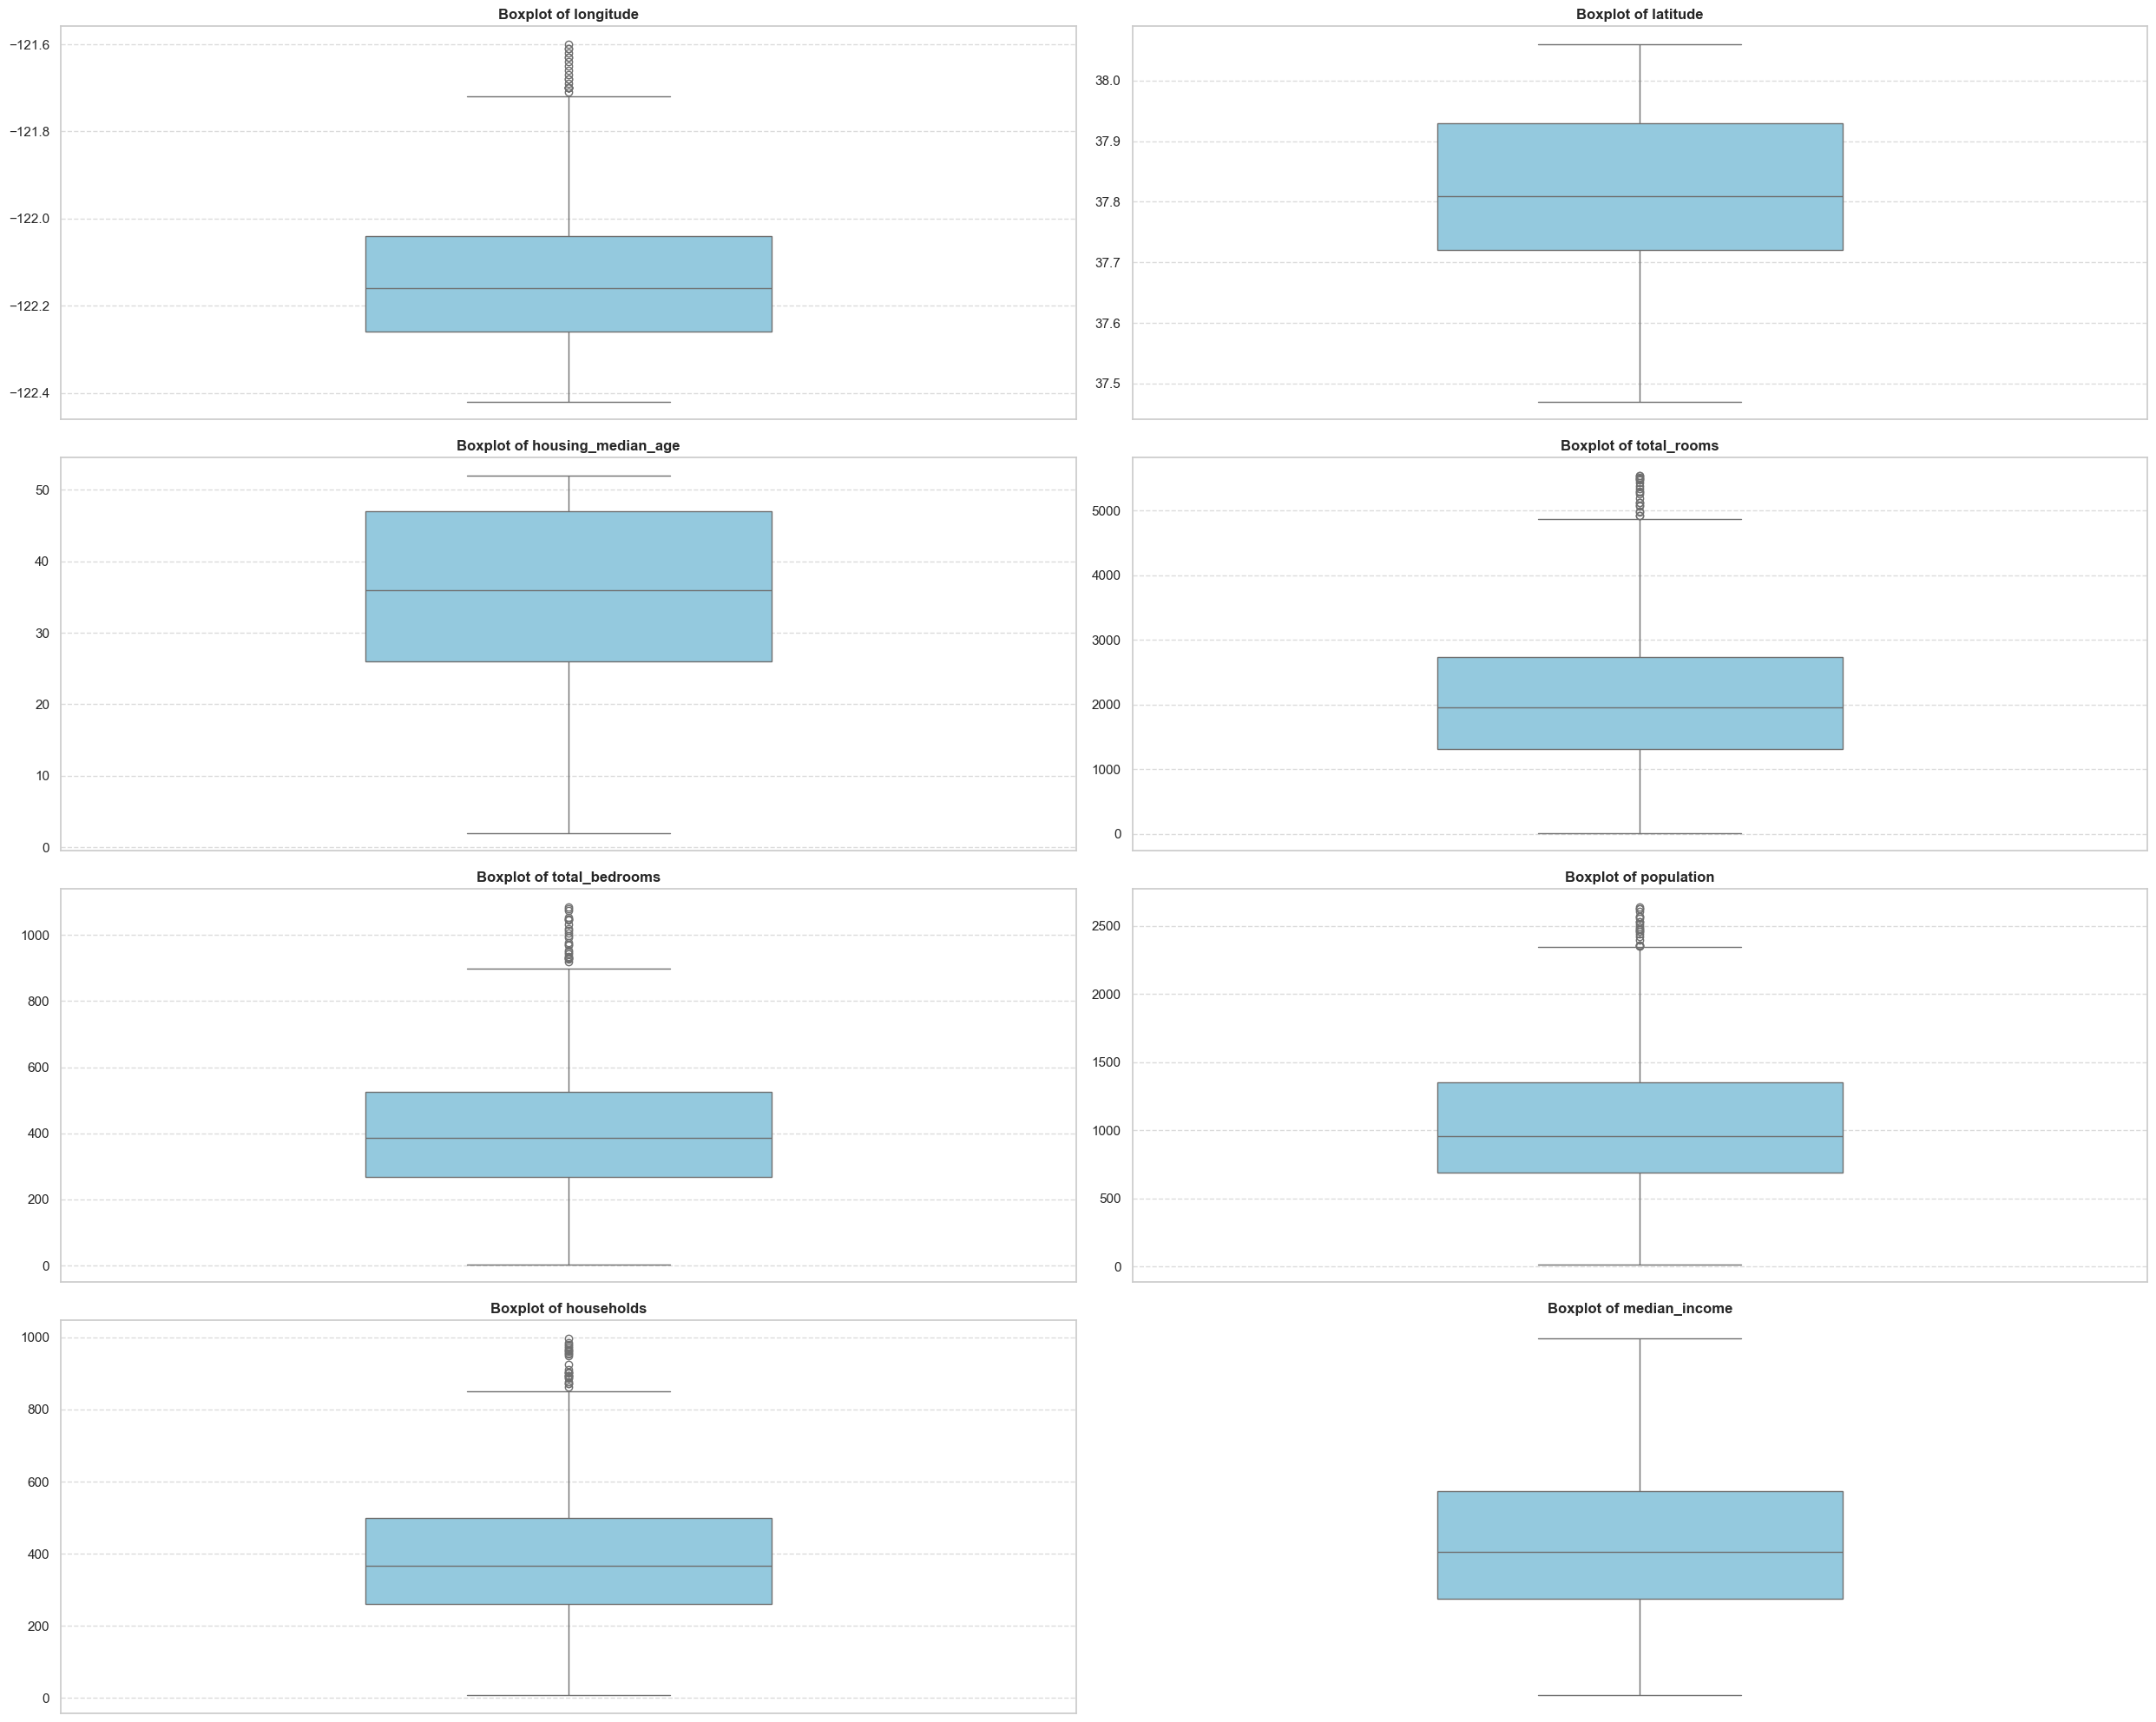

Jumlah outliers terdeteksi: 0


In [71]:
df_cleaned = df.loc[((df[feature_numerik] >= lower_bound) & (df[feature_numerik] <= upper_bound)).all(axis=1)]

#cek outliers
outliers = df_cleaned.loc[((df_cleaned[feature_numerik] < lower_bound) | (df_cleaned[feature_numerik] > upper_bound)).any(axis=1)]

fig, axes = plt.subplots(4, 2 ,figsize=(25,20))
axes = axes.flatten()
for i, col in enumerate(feature_numerik):
    sns.boxplot(y=df_cleaned[col], ax=axes[i], color='skyblue', width=0.4)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('') # Mengosongkan label y agar lebih bersih
    axes[i].grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan garis bantu
axes[-1].axis('off')
plt.tight_layout()
plt.show()
print(f'Jumlah outliers terdeteksi: {outliers.shape[0]}')

In [72]:
file_path = "../0.dataset/dataset_California_HousePrice_clean.csv"

if not path.exists(file_path):
    # Jika BELUM ADA, simpan data ke CSV
    df.to_csv(file_path, index=False)
    print("File belum ada. Berhasil menyimpan dataset baru!")
else:
    # Jika SUDAH ADA, lewati proses penyimpanan
    print("File sudah ada. Proses penyimpanan CSV dilewati (skip).")

df.head()

File belum ada. Berhasil menyimpan dataset baru!


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
